Block 2:

Conv → ReLU → Conv → ReLU → MaxPool

The VGG depth experiment progressively increases the number of VGG blocks while keeping the number of convolutional layers per block constant.

The models used in the depth experiment are:

| Model | Number of VGG Blocks | Total Convolutional Layers |
|---|---:|---:|
| VGG2 | 2 | 4 |
| VGG3 | 3 | 6 |
| VGG4 | 4 | 8 |
| VGG5 | 5 | 10 |

The purpose of this experiment is to observe how increasing depth changes the model's learning behavior and classification performance.

The experiment does not assume that a deeper network will necessarily perform better. Instead, the results will be used to examine how depth affects optimization, training and validation behavior, generalization, and test performance.

---

## 4. Dataset

The experiments use the **CIFAR-10 dataset**.

CIFAR-10 consists of:

- 50,000 training images
- 10,000 test images
- 10 image classes
- RGB images
- 32×32 pixel resolution

The original training set is divided into training and validation subsets. The official test set remains completely separate and is used only for final evaluation.

The dataset is stored in the project's Google Drive `data` directory so that it can be reused across experiments without downloading it again.

---

## 5. Experimental Conditions

The same training conditions are maintained across the VGG depth experiments so that depth remains the primary architectural variable.

- **Dataset:** CIFAR-10
- **Input size:** 32×32
- **Number of classes:** 10
- **Batch size:** 64
- **Optimizer:** SGD
- **Learning rate:** 0.01
- **Momentum:** 0.9
- **Loss function:** CrossEntropyLoss
- **Training epochs:** 20
- **Training augmentation:** Random Horizontal Flip
- **Convolution initialization:** Kaiming Normal
- **Final linear layer initialization:** Xavier Normal

The purpose of controlling these conditions is to isolate the effect of architectural depth and make the behavior of VGG2, VGG3, VGG4, and VGG5 directly comparable.

## Experiment 1: Studying the Effect of Depth

The first experiment focuses on the **depth of the VGG network**.

Here, I will change the number of VGG blocks while keeping the other main architectural settings controlled. The goal is to see how adding more convolutional blocks affects the way the model learns and performs on the **CIFAR-10 classification task**.

The base VGG architecture uses two blocks. From this base, I will compare models with different numbers of blocks while keeping the final feature representation and classification head consistent.

This experiment will help me understand whether making the network deeper changes its learning behavior, and how the added depth affects training and validation performance.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/CNN_Architecture_Study

/content/drive/MyDrive/CNN_Architecture_Study


In [3]:
# import libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch import optim
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from collections import OrderedDict
from PIL import Image
from tqdm import tqdm
from torch.utils.data import DataLoader
import cnn_utils

In [28]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
# create VGG Block class

class VGGBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2, 2)

        )

        self._initialize_weights()

    def _initialize_weights(self):
        for layer in self.modules():
            if isinstance(layer, nn.Conv2d):
                nn.init.kaiming_normal_(layer.weight, mode="fan_out", nonlinearity="relu")

                if layer.bias is not None:
                    nn.init.constant_(layer.bias, 0)



    def forward(self, x):
        return self.net(x)

In [6]:
class VGG(nn.Module):

    def __init__(self, num_blocks):
        super().__init__()

        channels = [64, 128, 256, 512, 512]

        blocks = []
        in_channels = 3

        for i in range(num_blocks):
            out_channels = channels[i]

            blocks.append(
                VGGBlock(in_channels, out_channels)
            )

            in_channels = out_channels

        self.blocks = nn.Sequential(*blocks)

        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(in_channels, 10)
        )

        self._initialize_classifier()

    def _initialize_classifier(self):

        linear_layer = self.classifier[2]

        nn.init.xavier_normal_(linear_layer.weight)
        nn.init.zeros_(linear_layer.bias)

    def forward(self, x):
        x = self.blocks(x)
        x = self.classifier(x)

        return x

In [7]:
import importlib

importlib.reload(cnn_utils)

<module 'cnn_utils' from '/content/drive/MyDrive/CNN_Architecture_Study/cnn_utils.py'>

In [8]:
import cnn_utils

cnn_utils.set_seed(42)

In [9]:
data_path = "/content/drive/MyDrive/CNN_Architecture_Study/data/cifar10"

train_dataset = datasets.CIFAR10(
    data_path,
    train=True,
    download=False
)

test_dataset = datasets.CIFAR10(
    data_path,
    train=False,
    download=False
)

In [10]:
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))

image, label = train_dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Image mode:", image.mode)
print("Label:", label)

Train samples: 50000
Test samples: 10000
Image type: <class 'PIL.Image.Image'>
Image size: (32, 32)
Image mode: RGB
Label: 6


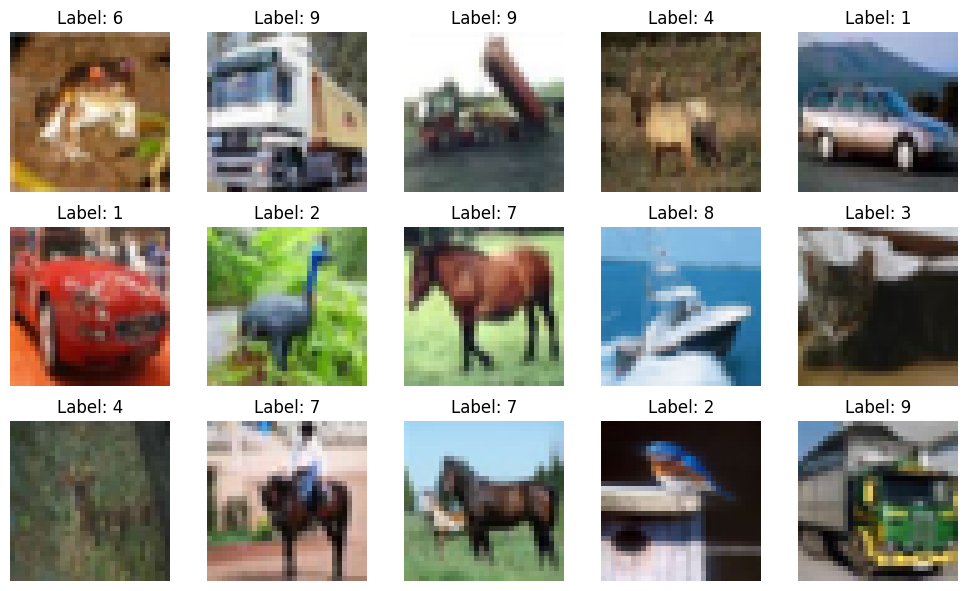

In [11]:
fig, axes = plt.subplots(3,5, figsize=(10,6))

for i, ax in enumerate(axes.flatten()):
  image, label = train_dataset[i]
  ax.imshow(image)
  ax.set_title(f"Label: {label}")
  ax.axis("off")

plt.tight_layout()
plt.show()


In [12]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


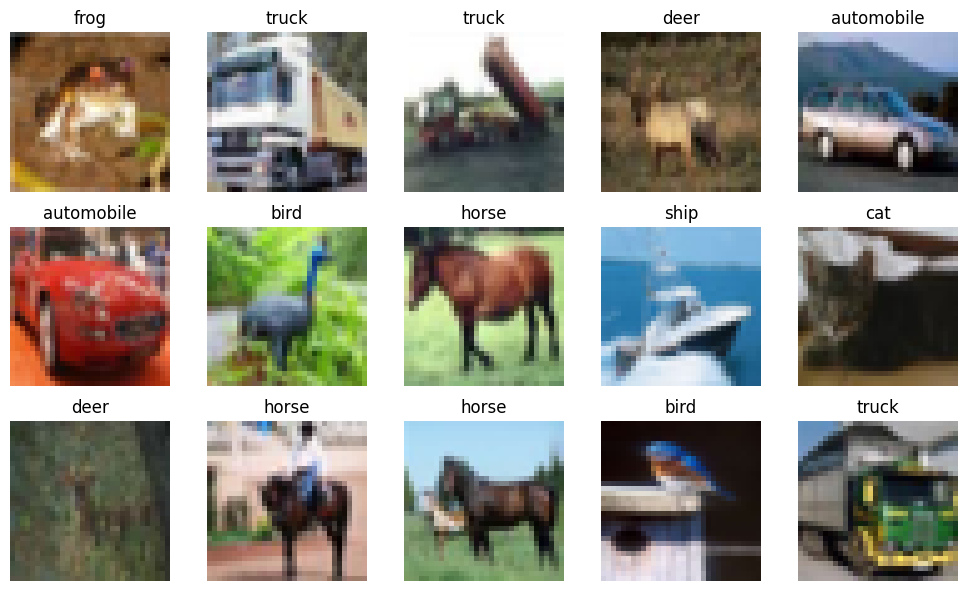

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 5, figsize=(10, 6))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image)
    ax.set_title(train_dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [14]:
train_transform, eval_transform = cnn_utils.create_transforms()

In [15]:
image, label = train_dataset[0]

transformed_image = train_transform(image)

print("Original type:", type(image))
print("Original size:", image.size)

print("Transformed type:", type(transformed_image))
print("Transformed shape:", transformed_image.shape)
print("Transformed dtype:", transformed_image.dtype)
print("Transformed min:", transformed_image.min().item())
print("Transformed max:", transformed_image.max().item())
print("Label:", label)

Original type: <class 'PIL.Image.Image'>
Original size: (32, 32)
Transformed type: <class 'torch.Tensor'>
Transformed shape: torch.Size([3, 32, 32])
Transformed dtype: torch.float32
Transformed min: -1.9894737005233765
Transformed max: 2.094278573989868
Label: 6


In [16]:
%%writefile -a cnn_utils.py

from torch.utils.data import random_split

def prepare_datasets(train_dataset, val_ratio=0.2, seed=42):
    """
    Split the training dataset into training and validation sets
    while keeping the original test dataset separate.

    Parameters
    ----------
    train_dataset : Dataset
        Original training dataset.

    test_dataset : Dataset
        Original test dataset.

    val_ratio : float
        Proportion of the training dataset used for validation.

    seed : int
        Random seed used for reproducible splitting.

    Returns
    -------
    train_data : Dataset
        Training subset.

    val_data : Dataset
        Validation subset.

    test_data : Dataset
        Original test dataset.
    """

    train_size = int((1 - val_ratio) * len(train_dataset))
    val_size = len(train_dataset) - train_size

    generator = torch.Generator().manual_seed(seed)

    train_data, val_data = random_split(
        train_dataset,
        [train_size, val_size],
        generator=generator
    )



    return train_data, val_data

Appending to cnn_utils.py


In [17]:
import importlib

importlib.reload(cnn_utils)

<module 'cnn_utils' from '/content/drive/MyDrive/CNN_Architecture_Study/cnn_utils.py'>

In [18]:
# preparing the dataset
train_data, val_data = cnn_utils.prepare_datasets(
    train_dataset,
    val_ratio=0.2,
    seed=42
)

In [19]:
print("Train size:", len(train_data))
print("Validation size:", len(val_data))
print("Test size:", len(test_dataset))

print("\nTrain type:", type(train_data))
print("Validation type:", type(val_data))
print("Test type:", type(test_dataset))

Train size: 40000
Validation size: 10000
Test size: 10000

Train type: <class 'torch.utils.data.dataset.Subset'>
Validation type: <class 'torch.utils.data.dataset.Subset'>
Test type: <class 'torchvision.datasets.cifar.CIFAR10'>


In [20]:
import importlib
importlib.reload(cnn_utils)

<module 'cnn_utils' from '/content/drive/MyDrive/CNN_Architecture_Study/cnn_utils.py'>

In [21]:
test_data = test_dataset

In [22]:
train_loader, val_loader, test_loader = cnn_utils.create_dataloaders(
    train_data,
    val_data,
    test_data,
    train_transform,
    eval_transform,
    batch_size=64,
    num_workers=2
)

In [23]:
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)

Image batch shape: torch.Size([64, 3, 32, 32])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64


In [24]:
vgg2 = VGG(num_blocks=2)

In [25]:
x = torch.randn(64, 3, 32, 32)

outputs = vgg2(x)

print("Input shape:", x.shape)
print("Output shape:", outputs.shape)

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])


In [30]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [31]:
vgg2 = VGG(num_blocks=2)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg2.parameters(),
    lr=0.01,
    momentum=0.9
)

In [32]:
vgg2, history_vgg2 = cnn_utils.train_model(
    vgg2,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.8041 | Train Acc: 0.3196 | Val Loss: 1.6080 | Val Acc: 0.3960
Epoch [2/20] Train Loss: 1.4815 | Train Acc: 0.4661 | Val Loss: 1.3366 | Val Acc: 0.5206
Epoch [3/20] Train Loss: 1.2863 | Train Acc: 0.5427 | Val Loss: 1.2177 | Val Acc: 0.5666
Epoch [4/20] Train Loss: 1.1503 | Train Acc: 0.5938 | Val Loss: 1.0639 | Val Acc: 0.6242
Epoch [5/20] Train Loss: 1.0497 | Train Acc: 0.6301 | Val Loss: 1.0124 | Val Acc: 0.6446
Epoch [6/20] Train Loss: 0.9664 | Train Acc: 0.6601 | Val Loss: 0.9315 | Val Acc: 0.6679
Epoch [7/20] Train Loss: 0.9042 | Train Acc: 0.6817 | Val Loss: 0.8762 | Val Acc: 0.6882
Epoch [8/20] Train Loss: 0.8446 | Train Acc: 0.7055 | Val Loss: 0.8856 | Val Acc: 0.6932
Epoch [9/20] Train Loss: 0.7951 | Train Acc: 0.7240 | Val Loss: 0.8080 | Val Acc: 0.7207
Epoch [10/20] Train Loss: 0.7507 | Train Acc: 0.7381 | Val Loss: 0.8013 | Val Acc: 0.7150
Epoch [11/20] Train Loss: 0.7159 | Train Acc: 0.7489 | Val Loss: 0.7501 | Val Acc: 0.7377
Epoch [12/20] Train

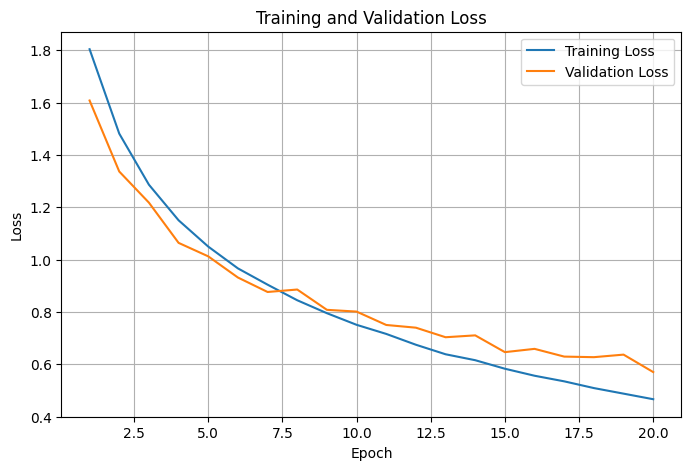

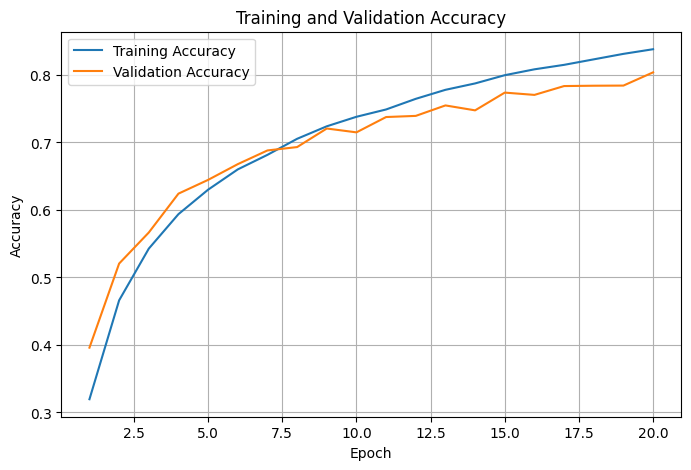

In [33]:
cnn_utils.plot_history(history_vgg2)

In [34]:
from IPython.testing import test
test_loss, test_accuracy = cnn_utils.test_model(
    vgg2,
    test_loader,
    loss_function,
    device
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)



Test Loss: 0.5940
Test Accuracy: 0.7939
Test loss: 0.5940403721809387
Test accuracy: 0.7939


## Experiment 1: VGG2

The first model in the depth experiment is VGG2. It has two VGG blocks, with two convolution layers in each block, giving a total of four convolution layers.

The model was trained on CIFAR-10 for 20 epochs using SGD with a learning rate of 0.01 and momentum of 0.9. The batch size was 64 and CrossEntropyLoss was used.

### Training Results

The model continued to learn throughout the 20 epochs.

- Final training loss: **0.4663**
- Final validation loss: **0.5700**
- Final training accuracy: **83.82%**
- Final validation accuracy: **80.39%**

The training and validation loss both decreased over the 20 epochs, while both training and validation accuracy increased.

There is a small gap between the training and validation accuracy at the end of training. The model did not show a large increase in validation loss toward the end of the experiment.

### Test Set Results

After training, the model was evaluated on the original CIFAR-10 test set, which was not used during training.

- Test loss: **0.5940**
- Test accuracy: **79.39%**

The test accuracy is slightly lower than the final validation accuracy, which is expected since the test set was kept separate from the training process.

### Training Curves

The training and validation curves are shown below.

### Observation

VGG2 was able to learn the CIFAR-10 classification task steadily over the 20 epochs. The model reached 83.82% training accuracy, 80.39% validation accuracy, and 79.39% test accuracy. This result will be used as the reference point for the next depth experiment, VGG3.

## Experiment 2: VGG3

The second model adds one more VGG block to the architecture.

VGG3 has three VGG blocks, with two convolution layers in each block, giving a total of six convolution layers.

The main purpose of this experiment is to see how adding another block changes the way the model learns compared with VGG2.

The training conditions remain the same as the first experiment:

- Dataset: **CIFAR-10**
- Input size: **32 × 32**
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Training augmentation: **RandomHorizontalFlip**
- Initialization: **Kaiming normal for convolution layers and Xavier normal for the final linear layer**

The only architectural change is the addition of the third VGG block.

### VGG3 Structure

```text
Block 1:
Conv → ReLU → Conv → ReLU → MaxPool

Block 2:
Conv → ReLU → Conv → ReLU → MaxPool

Block 3:
Conv → ReLU → Conv → ReLU → MaxPool

In [35]:
vgg3 = VGG(num_blocks=3)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg3.parameters(),
    lr=0.01,
    momentum=0.9
)

In [36]:
vgg3, history_vgg3 = cnn_utils.train_model(
    vgg3,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.6988 | Train Acc: 0.3628 | Val Loss: 1.4324 | Val Acc: 0.4761
Epoch [2/20] Train Loss: 1.2889 | Train Acc: 0.5301 | Val Loss: 1.2531 | Val Acc: 0.5638
Epoch [3/20] Train Loss: 1.0492 | Train Acc: 0.6272 | Val Loss: 0.9833 | Val Acc: 0.6466
Epoch [4/20] Train Loss: 0.8870 | Train Acc: 0.6882 | Val Loss: 0.8256 | Val Acc: 0.7083
Epoch [5/20] Train Loss: 0.7676 | Train Acc: 0.7315 | Val Loss: 0.7148 | Val Acc: 0.7477
Epoch [6/20] Train Loss: 0.6733 | Train Acc: 0.7662 | Val Loss: 0.6518 | Val Acc: 0.7735
Epoch [7/20] Train Loss: 0.5936 | Train Acc: 0.7937 | Val Loss: 0.6423 | Val Acc: 0.7715
Epoch [8/20] Train Loss: 0.5317 | Train Acc: 0.8149 | Val Loss: 0.5884 | Val Acc: 0.7945
Epoch [9/20] Train Loss: 0.4749 | Train Acc: 0.8366 | Val Loss: 0.5917 | Val Acc: 0.7909
Epoch [10/20] Train Loss: 0.4328 | Train Acc: 0.8512 | Val Loss: 0.5337 | Val Acc: 0.8149
Epoch [11/20] Train Loss: 0.3820 | Train Acc: 0.8668 | Val Loss: 0.5441 | Val Acc: 0.8138
Epoch [12/20] Train

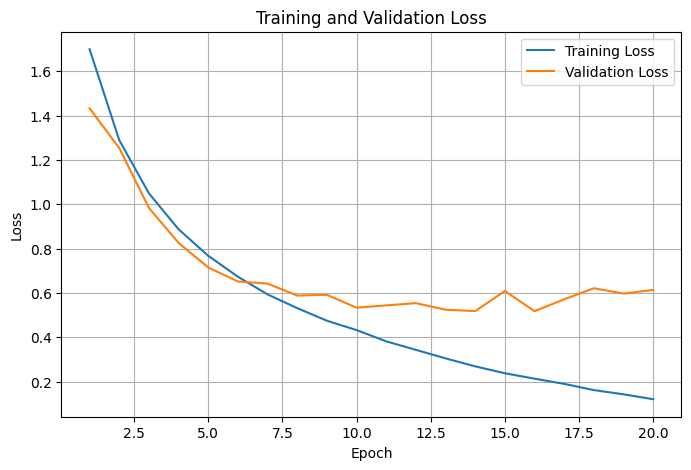

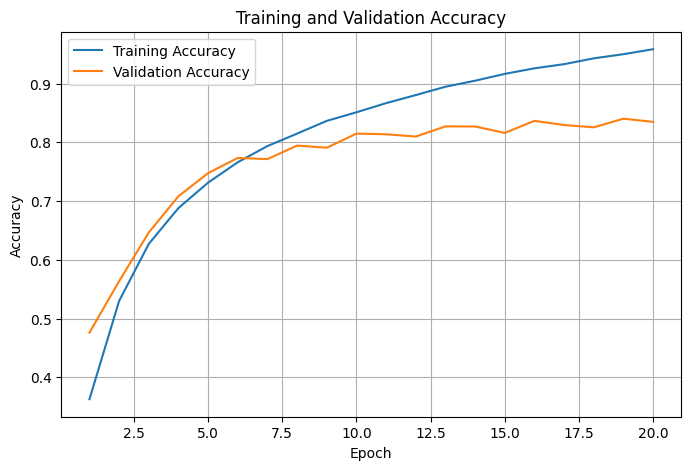

In [37]:
cnn_utils.plot_history(history_vgg3)

In [38]:
test_loss, test_accuracy = cnn_utils.test_model(
    vgg3,
    test_loader,
    loss_function,
    device
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test Loss: 0.6334
Test Accuracy: 0.8338
Test loss: 0.6333927819252014
Test accuracy: 0.8338


## Experiment 2: VGG3 Results

VGG3 was trained for 20 epochs using the same training conditions as VGG2. The only change was the addition of a third VGG block, increasing the network from four to six convolution layers.

### Training Results

The model showed a clear improvement in learning as training progressed.

- Final training loss: **0.1211**
- Final validation loss: **0.6138**
- Final training accuracy: **95.86%**
- Final validation accuracy: **83.49%**

The training loss continued to decrease throughout the experiment, while the training accuracy increased to 95.86%.

The validation loss decreased during the early stages of training but started to fluctuate and increase later in the experiment. At the same time, validation accuracy stopped improving at the same rate as training accuracy. This shows evidence of **overfitting** in the later epochs.

### Test Set Results

After training, VGG3 was evaluated on the untouched CIFAR-10 test set.

- Test loss: **0.6334**
- Test accuracy: **83.38%**

The test accuracy was higher than the VGG2 test accuracy of **79.39%**.

### Comparison with VGG2

VGG3 has six convolution layers compared with four in VGG2.

| Metric | VGG2 | VGG3 |
|---|---:|---:|
| Convolution layers | 4 | 6 |
| Training accuracy | 83.82% | 95.86% |
| Validation accuracy | 80.39% | 83.49% |
| Test accuracy | 79.39% | 83.38% |
| Test loss | 0.5940 | 0.6334 |

The results show that adding the third VGG block allowed the model to achieve higher training, validation, and test accuracy than VGG2. However, the much larger gap between training and validation accuracy in VGG3 also shows that the deeper model is fitting the training data more strongly.

### Observation

Increasing the depth from VGG2 to VGG3 improved the classification accuracy on both the validation and test sets. At the same time, the deeper model showed more evidence of overfitting, especially toward the end of training.

This gives us a useful comparison for the next experiment, where the depth will be increased again with VGG4.

## Experiment 3: VGG4

The third model increases the depth to four VGG blocks. Each block still contains two convolution layers, giving a total of eight convolution layers.

The purpose of this experiment is to see how another increase in depth affects the learning behavior of the model compared with VGG2 and VGG3.

The training conditions remain the same:

- Dataset: **CIFAR-10**
- Input size: **32 × 32**
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Training augmentation: **RandomHorizontalFlip**
- Initialization: **Kaiming normal for convolution layers and Xavier normal for the final linear layer**

The only architectural change is the addition of a fourth VGG block.

### VGG4 Structure

```text
Block 1:
Conv → ReLU → Conv → ReLU → MaxPool

Block 2:
Conv → ReLU → Conv → ReLU → MaxPool

Block 3:
Conv → ReLU → Conv → ReLU → MaxPool

Block 4:
Conv → ReLU → Conv → ReLU → MaxPool

In [40]:
vgg4 = VGG(num_blocks=4)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg4.parameters(),
    lr=0.01,
    momentum=0.9
)

In [41]:
vgg4, history_vgg4 = cnn_utils.train_model(
    vgg4,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.6397 | Train Acc: 0.3899 | Val Loss: 1.2728 | Val Acc: 0.5365
Epoch [2/20] Train Loss: 1.1690 | Train Acc: 0.5795 | Val Loss: 1.1432 | Val Acc: 0.5896
Epoch [3/20] Train Loss: 0.8962 | Train Acc: 0.6837 | Val Loss: 0.8043 | Val Acc: 0.7184
Epoch [4/20] Train Loss: 0.7182 | Train Acc: 0.7517 | Val Loss: 0.7094 | Val Acc: 0.7582
Epoch [5/20] Train Loss: 0.6114 | Train Acc: 0.7878 | Val Loss: 0.6540 | Val Acc: 0.7681
Epoch [6/20] Train Loss: 0.5313 | Train Acc: 0.8163 | Val Loss: 0.5885 | Val Acc: 0.7950
Epoch [7/20] Train Loss: 0.4554 | Train Acc: 0.8416 | Val Loss: 0.5439 | Val Acc: 0.8125
Epoch [8/20] Train Loss: 0.4007 | Train Acc: 0.8597 | Val Loss: 0.5814 | Val Acc: 0.8026
Epoch [9/20] Train Loss: 0.3458 | Train Acc: 0.8826 | Val Loss: 0.5509 | Val Acc: 0.8159
Epoch [10/20] Train Loss: 0.2900 | Train Acc: 0.9011 | Val Loss: 0.5866 | Val Acc: 0.8107
Epoch [11/20] Train Loss: 0.2494 | Train Acc: 0.9140 | Val Loss: 0.6251 | Val Acc: 0.8126
Epoch [12/20] Train

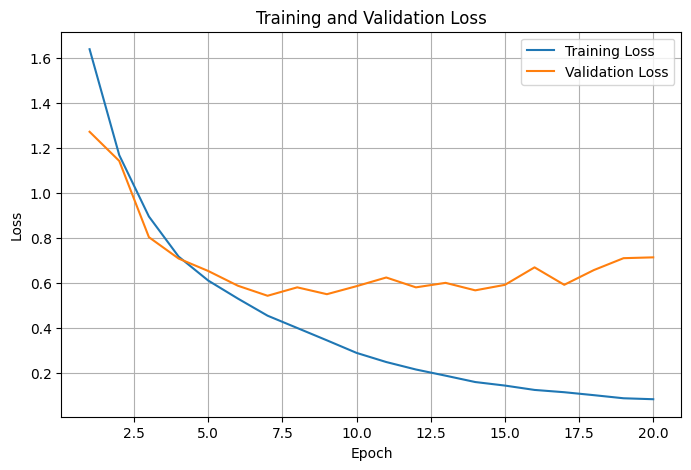

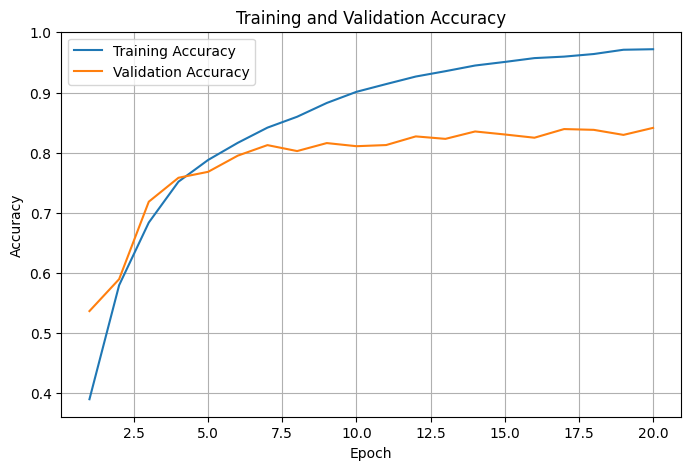

In [42]:
cnn_utils.plot_history(history_vgg4)

In [43]:
test_loss_vgg4, test_accuracy_vgg4 = cnn_utils.test_model(
    vgg4,
    test_loader,
    loss_function,
    device
)

print("Test loss:", test_loss_vgg4)
print("Test accuracy:", test_accuracy_vgg4)

Test Loss: 0.7479
Test Accuracy: 0.8417
Test loss: 0.747872452545166
Test accuracy: 0.8417


## Experiment 3: VGG4 Results

VGG4 was trained for 20 epochs using the same training conditions as VGG2 and VGG3. The model has four VGG blocks, giving a total of eight convolution layers.

### Training Results

The model learned the training data very well, with training accuracy reaching **97.20%** by the final epoch.

- Final training loss: **0.0841**
- Final validation loss: **0.7146**
- Final training accuracy: **97.20%**
- Final validation accuracy: **84.12%**

The training loss continued to decrease throughout the experiment, while the validation loss started to fluctuate and increase during the later epochs. The difference between training and validation accuracy also became larger as training progressed. This provides clear evidence of overfitting.

### Test Set Results

After training, VGG4 was evaluated on the untouched CIFAR-10 test set.

- Test loss: **0.7479**
- Test accuracy: **84.17%**

The test accuracy is slightly higher than the final validation accuracy.

### Comparison with Previous Models

| Metric | VGG2 | VGG3 | VGG4 |
|---|---:|---:|---:|
| Conv layers | 4 | 6 | 8 |
| Training accuracy | 83.82% | 95.86% | 97.20% |
| Validation accuracy | 80.39% | 83.49% | 84.12% |
| Test accuracy | 79.39% | 83.38% | 84.17% |
| Test loss | 0.5940 | 0.6334 | 0.7479 |

### Observation

Increasing the depth from VGG3 to VGG4 further increased the training, validation, and test accuracy. However, the deeper model also showed stronger overfitting, with training accuracy reaching 97.20% while validation accuracy remained at 84.12%.

The improvement in test accuracy from VGG3 to VGG4 was relatively small compared with the large increase in training accuracy. This suggests that the additional depth helped the model fit the training data much more strongly, but the improvement in generalization was smaller.

VGG4 gives us another useful point in the depth experiment before moving to a deeper architecture.

## Experiment 4: VGG5

The fourth model increases the depth to five VGG blocks. Each block contains two convolution layers, giving a total of ten convolution layers.

The purpose of this experiment is to continue studying how increasing the depth of the VGG architecture affects learning and generalization.

The training conditions remain the same as the previous experiments:

- Dataset: **CIFAR-10**
- Input size: **32 × 32**
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Training augmentation: **RandomHorizontalFlip**
- Initialization: **Kaiming normal for convolution layers and Xavier normal for the final linear layer**

The only architectural change is the addition of a fifth VGG block.

### VGG5 Structure

```text
Block 1:
Conv → ReLU → Conv → ReLU → MaxPool

Block 2:
Conv → ReLU → Conv → ReLU → MaxPool

Block 3:
Conv → ReLU → Conv → ReLU → MaxPool

Block 4:
Conv → ReLU → Conv → ReLU → MaxPool

Block 5:
Conv → ReLU → Conv → ReLU → MaxPool

In [44]:
vgg5 = VGG(num_blocks=5)

loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    vgg5.parameters(),
    lr=0.01,
    momentum=0.9
)

In [45]:
vgg5, history_vgg5 = cnn_utils.train_model(
    vgg5,
    train_loader,
    val_loader,
    loss_function,
    optimizer,
    device,
    epochs=20
)

Epoch [1/20] Train Loss: 1.6074 | Train Acc: 0.4055 | Val Loss: 1.2814 | Val Acc: 0.5496
Epoch [2/20] Train Loss: 1.0945 | Train Acc: 0.6081 | Val Loss: 0.9330 | Val Acc: 0.6685
Epoch [3/20] Train Loss: 0.8338 | Train Acc: 0.7073 | Val Loss: 0.9033 | Val Acc: 0.6850
Epoch [4/20] Train Loss: 0.6846 | Train Acc: 0.7621 | Val Loss: 0.7521 | Val Acc: 0.7431
Epoch [5/20] Train Loss: 0.5881 | Train Acc: 0.7975 | Val Loss: 0.6627 | Val Acc: 0.7710
Epoch [6/20] Train Loss: 0.5094 | Train Acc: 0.8243 | Val Loss: 0.6109 | Val Acc: 0.7841
Epoch [7/20] Train Loss: 0.4378 | Train Acc: 0.8489 | Val Loss: 0.6364 | Val Acc: 0.7837
Epoch [8/20] Train Loss: 0.3770 | Train Acc: 0.8685 | Val Loss: 0.5784 | Val Acc: 0.8035
Epoch [9/20] Train Loss: 0.3323 | Train Acc: 0.8855 | Val Loss: 0.5919 | Val Acc: 0.8039
Epoch [10/20] Train Loss: 0.2917 | Train Acc: 0.9006 | Val Loss: 0.5661 | Val Acc: 0.8112
Epoch [11/20] Train Loss: 0.2517 | Train Acc: 0.9134 | Val Loss: 0.6039 | Val Acc: 0.8111
Epoch [12/20] Train

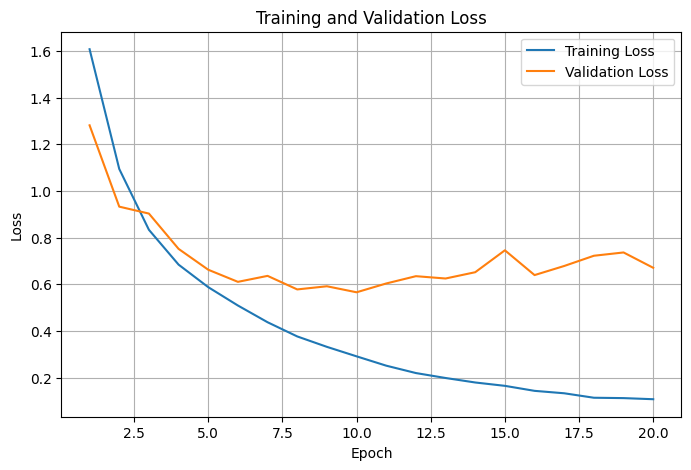

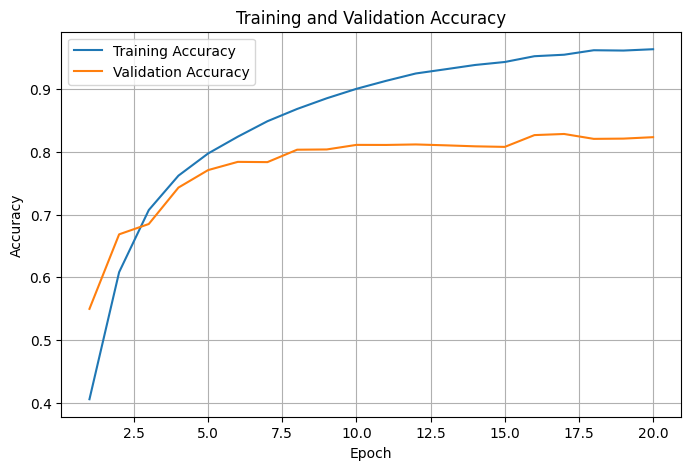

In [46]:
cnn_utils.plot_history(history_vgg5)

In [47]:
test_loss, test_accuracy = cnn_utils.test_model(
    vgg5,
    test_loader,
    loss_function,
    device
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test Loss: 0.7280
Test Accuracy: 0.8228
Test loss: 0.7279645537853241
Test accuracy: 0.8228


## Experiment 4: VGG5 Results

VGG5 was trained for 20 epochs using the same training conditions as the previous VGG experiments. It contains five VGG blocks, giving a total of ten convolution layers.

### Training Results

The model learned the training data very strongly. Training accuracy increased to **96.38%** by the final epoch, while the validation accuracy reached **82.35%**.

- Final training loss: **0.1080**
- Final validation loss: **0.6710**
- Final training accuracy: **96.38%**
- Final validation accuracy: **82.35%**

The training loss continued to decrease throughout the experiment. However, the validation loss began to fluctuate and increase after the early epochs, while validation accuracy largely stopped improving. This shows clear evidence of overfitting as the model became deeper.

### Test Set Results

After training, VGG5 was evaluated on the untouched CIFAR-10 test set.

- Test loss: **0.7280**
- Test accuracy: **82.28%**

### Comparison with Previous Models

| Metric | VGG2 | VGG3 | VGG4 | VGG5 |
|---|---:|---:|---:|---:|
| Conv layers | 4 | 6 | 8 | 10 |
| Training accuracy | 83.82% | 95.86% | 97.20% | 96.38% |
| Validation accuracy | 80.39% | 83.49% | 84.12% | 82.35% |
| Test accuracy | 79.39% | 83.38% | 84.17% | 82.28% |
| Test loss | 0.5940 | 0.6334 | 0.7479 | 0.7280 |

### Observation

Increasing the depth from VGG2 to VGG5 did not result in a continuous improvement in validation and test performance.

VGG3 and VGG4 improved the validation and test accuracy compared with VGG2. However, VGG5 showed a decrease in both validation and test accuracy, while still achieving very high training accuracy.

This suggests that increasing the depth beyond four blocks caused the model to fit the training data more strongly without producing a corresponding improvement on unseen data.

Overall, the depth experiment shows that simply adding more VGG blocks does not guarantee better generalization.

## Experiment 2: Studying the Effect of Width

The second experiment focuses on the **width of the VGG network**.

For this experiment, I will keep the depth fixed at four VGG blocks and change the number of channels used in the convolution layers. The purpose is to see how increasing or decreasing the number of channels affects the model's learning behavior and generalization.

VGG4 is used as the base architecture because it was the deepest model in the first experiment with the highest test accuracy.

The main training conditions remain unchanged:

- Dataset: **CIFAR-10**
- Input size: **32 × 32**
- Batch size: **64**
- Optimizer: **SGD**
- Learning rate: **0.01**
- Momentum: **0.9**
- Loss function: **CrossEntropyLoss**
- Training epochs: **20**
- Training augmentation: **RandomHorizontalFlip**
- Initialization: **Kaiming normal for convolution layers and Xavier normal for the final linear layer**

The depth remains fixed at four VGG blocks. Only the number of channels is changed.

### Width Configurations

| Model | Block 1 | Block 2 | Block 3 | Block 4 |
|---|---:|---:|---:|---:|
| VGG4-Narrow | 32 | 64 | 128 | 256 |
| VGG4-Base | 64 | 128 | 256 | 512 |
| VGG4-Wide | 96 | 192 | 384 | 768 |

The goal is to observe how changing the width of the network affects training accuracy, validation accuracy, loss, and test performance.

In [48]:
mkdir -p /content/drive/MyDrive/CNN_Architecture_Study/data/models

In [49]:
model_path = "/content/drive/MyDrive/CNN_Architecture_Study/data/models"

torch.save(vgg2.state_dict(), f"{model_path}/vgg2_final.pth")
torch.save(vgg3.state_dict(), f"{model_path}/vgg3_final.pth")
torch.save(vgg4.state_dict(), f"{model_path}/vgg4_final.pth")
torch.save(vgg5.state_dict(), f"{model_path}/vgg5_final.pth")

In [50]:
model_path = "/content/drive/MyDrive/CNN_Architecture_Study/data/models"

torch.save(history_vgg2, f"{model_path}/history_vgg2.pth")
torch.save(history_vgg3, f"{model_path}/history_vgg3.pth")
torch.save(history_vgg4, f"{model_path}/history_vgg4.pth")
torch.save(history_vgg5, f"{model_path}/history_vgg5.pth")

In [52]:
!git add notebooks/VGG_Experiment.ipynb
!git commit -m "Complete VGG depth experiment"
!git push origin main

[main b0be2cd] Complete VGG depth experiment
 1 file changed, 1 insertion(+), 1 deletion(-)
fatal: could not read Username for 'https://github.com': No such device or address


In [ ]:
from getpass import getpass
import subprocess

token = getpass("Paste your GitHub token: ")

subprocess.run(
    ["gh", "auth", "login", "--with-token"],
    input=token + "\n",
    text=True
)

subprocess.run(["gh", "auth", "setup-git"])